# 05 — Black–Scholes: Gamma por Diferencias Finitas y fallo del Pathwise

**Objetivo del notebook.** Estimar la $\Gamma$ de una opción europea bajo Black–Scholes mediante diferencias finitas, y **cuantificar empíricamente** por qué el método pathwise falla para Griegas de segundo orden.

A diferencia de los notebooks 02–04 (Delta, Vega, Rho), aquí no se hace una comparación PW vs. FD en condiciones de igualdad: el método pathwise produce un estimador idénticamente nulo, lo que hace inaplicable el contraste habitual.

## Estructura

1. **Demostración empírica del fallo de PW.**
2. **FD centrada de segundo orden:**

$$\Gamma^{FD} = \frac{V(S_0+h) - 2V(S_0) + V(S_0-h)}{h^2}.$$

3. Validación, convergencia y sensibilidad respecto a $h$.

## Por qué falla pathwise para $\Gamma$

El estimador pathwise para Delta es

$$\Delta^{PW} = e^{-rT}\,\mathbb{E}\!\left[\mathbf{1}_{S_T > K}\,\frac{S_T}{S_0}\right].$$

La intercambiabilidad $\partial - \mathbb{E}$ requiere que el integrando sea diferenciable c.s. respecto al parámetro. Para Delta funciona porque $(S_T - K)^+$ es derivable salvo en el conjunto $\{S_T = K\}$ (medida nula). Para $\Gamma$, en cambio, habría que derivar **otra vez** un integrando que ya contiene la indicadora $\mathbf{1}_{S_T > K}$: la derivada distribucional de $\mathbf{1}_{S_T > K}$ es una delta de Dirac concentrada en $S_T = K$, que el estimador Monte Carlo estándar no captura. Formalmente, el estimador pathwise directo da cero porque $\partial \mathbf{1}_{S_T > K}/\partial S_0 = 0$ casi seguramente.


In [4]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bs_utils import (BS_gamma,GeneratePathsGBM_givenZ,FD_Gamma, opcion_europea)

np.set_printoptions(suppress=True, precision=6)


## 1. Parámetros del experimento


In [5]:
CP        = 'call'
S0        = 100.0
K         = 100.0
sigma     = 0.20
r         = 0.05
T         = 1.0
t         = 0.0
NoOfSteps = 1

SEED      = 3


## 2. Demostración empírica del fallo del estimador pathwise

Implementamos el estimador pathwise directo obtenido aplicando la regla de la cadena puntualmente a la doble derivada del payoff descontado:

$$\Gamma^{PW} = e^{-rT}\,\mathbb{E}\!\left[\Phi''(S_T)\left(\tfrac{\partial S_T}{\partial S_0}\right)^2 + \Phi'(S_T)\,\tfrac{\partial^2 S_T}{\partial S_0^2}\right].$$

Bajo Black–Scholes:

- $\Phi'(S_T) = \mathbf{1}_{S_T > K}$, y $\Phi''(S_T) = 0$ casi seguramente (la masa de Dirac en $S_T = K$ no se captura por una media muestral).
- $\partial S_T/\partial S_0 = S_T/S_0$, $\partial^2 S_T/\partial S_0^2 = 0$ (porque $S_T$ es lineal en $S_0$ a $\omega$ fijo).

Ambos términos se anulan trayectoria a trayectoria, así que la media muestral es exactamente cero.


In [7]:
def PathwiseGamma_directo(CP, S0, S, K, r, T):
    """
    Estimador pathwise directo de Gamma.

    Aplicando la regla de la cadena al integrando del estimador de Delta:
        - segunda derivada del payoff: 0 c.s.
        - segunda derivada de S_T respecto a S_0: 0 c.s. (S_T es lineal en S_0).
    Implementado con su forma explícita para que el resultado nulo no quede
    oculto en una simplificación analítica previa.
    """
    ST = S[:, -1]
    
    # Derivadas a nivel trayectoria
    dST_dS0   = ST / S0
    d2ST_dS02 = np.zeros_like(ST)        # S_T es lineal en S_0
    
    # Derivadas del payoff (call). Para put, mismo argumento.
    if CP.lower() == 'call':
        f_prime  = (ST > K).astype(float)
    elif CP.lower() == 'put':
        f_prime  = -(ST < K).astype(float)
    else:
        raise ValueError("CP debe ser 'call' o 'put'")
    f_second = np.zeros_like(ST)         # 0 c.s. (delta de Dirac en S_T = K)
    
    integrand = f_second * dST_dS0**2 + f_prime * d2ST_dS02
    return np.exp(-r * T) * np.mean(integrand)


In [8]:
# Evaluamos el estimador para varios N y comparamos con la Gamma analítica
gamma_BS = BS_gamma(S0, K, sigma, t, T, r)

N_list = [1_000, 10000, 100000, 1000000]
rows = []
rng = np.random.default_rng(SEED)

for N in N_list:
    Z = rng.normal(0.0, 1.0, (N, NoOfSteps))
    paths = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0)
    gamma_PW_naive = PathwiseGamma_directo(CP, S0, paths["S"], K, r, T)
    rows.append([N, gamma_PW_naive, gamma_BS, abs(gamma_PW_naive - gamma_BS)])

df_pw_fail = pd.DataFrame(rows, columns=["N", "Gamma_PW_naive", "Gamma_BS", "Error_abs"])
df_pw_fail


,N,Gamma_PW_naive,Gamma_BS,Error_abs
0,1000,0.0,0.018762,0.018762
1,10000,0.0,0.018762,0.018762
2,100000,0.0,0.018762,0.018762
3,1000000,0.0,0.018762,0.018762


**Lectura.** El estimador pathwise devuelve **exactamente cero** (a precisión de máquina) para todo $N$, mientras que la $\Gamma$ analítica es estrictamente positiva (~0.02 en este escenario ATM). El error absoluto coincide con el valor de $\Gamma_{BS}$, confirmando que no hay convergencia: el estimador no es ruidoso, está estructuralmente equivocado.

## 3. Estimador FD: validación puntual


In [9]:
N = 100_000
h = 0.5         

rng = np.random.default_rng(SEED)
Z = rng.normal(0.0, 1.0, (N, NoOfSteps))

gamma_FD = FD_Gamma(CP, S0, K, sigma, T, r, h, Z)

print(f"Gamma BS (analítica): {gamma_BS:.6f}")
print(f"Gamma FD (centrada):  {gamma_FD:.6f}    error abs = {abs(gamma_FD - gamma_BS):.2e}")


Gamma BS (analítica): 0.018762
Gamma FD (centrada):  0.018907    error abs = 1.45e-04


**Lectura.** El FD centrado de segundo orden recupera la $\Gamma$ analítica. La sensibilidad al paso $h$ es más severa que en las Griegas de primer orden: el divisor pasa de $2h$ a $h^2$, por lo que la varianza del estimador se infla como $1/h^4$ en ausencia de CRN.


## 4. Convergencia frente a $N$


In [10]:
N_list = [1000, 5000, 10000, 50000, 100000]
results = []

rng = np.random.default_rng(SEED)
for N in N_list:
    Z = rng.normal(0.0, 1.0, (N, NoOfSteps))
    gamma_FD = FD_Gamma(CP, S0, K, sigma, T, r, h, Z)
    
    results.append([
        N,
        gamma_FD, abs(gamma_FD - gamma_BS),
        1.0/np.sqrt(N)
    ])

df_N = pd.DataFrame(results, columns=["N", "Gamma_FD", "Error_FD", "MC_rate"])
df_N


,N,Gamma_FD,Error_FD,MC_rate
0,1000,0.017704,0.001058,0.031623
1,5000,0.018338,0.000424,0.014142
2,10000,0.016992,0.001770,0.010000
3,50000,0.018738,0.000024,0.004472
4,100000,0.019102,0.000340,0.003162


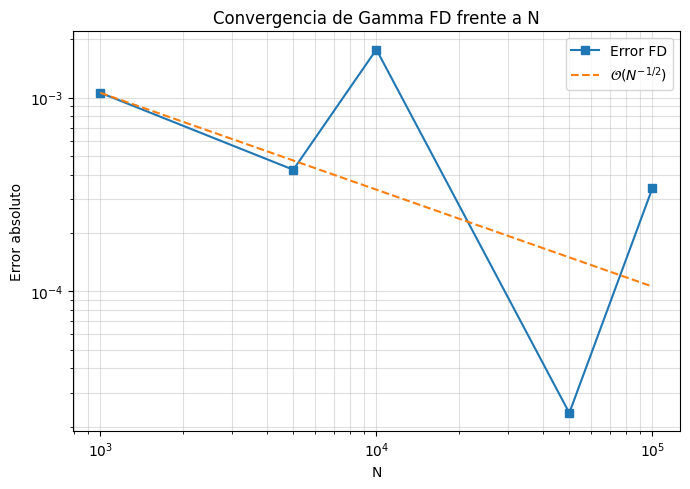

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(df_N["N"], df_N["Error_FD"], "s-", label="Error FD")
scale = df_N["Error_FD"].iloc[0] * np.sqrt(df_N["N"].iloc[0])
ax.loglog(df_N["N"], scale/np.sqrt(df_N["N"]), "--",
          label=r"$\mathcal{O}(N^{-1/2})$")
ax.set_xlabel("N")
ax.set_ylabel("Error absoluto")
ax.set_title("Convergencia de Gamma FD frente a N")
ax.grid(True, which="both", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()


**Lectura.** Convergencia $\mathcal{O}(N^{-1/2})$ confirmada para FD. La constante multiplicativa es mayor que en Delta y Vega: el operador de segunda diferencia amplifica el ruido muestral por el factor $1/h^2$.


## 5. Sensibilidad respecto al paso $h$

Para Gamma, el compromiso sesgo–varianza es **más agudo** que para Delta y Vega:

- Sesgo de truncamiento: $\mathcal{O}(h^2)$ (segunda diferencia centrada).
- Varianza del estimador: sin CRN crece como $1/h^4$ a $h$ pequeño (vs. $1/h^2$ para primer orden), con CRN se suaviza aunque no desaparece por completo.

El $h^\star$ óptimo es por tanto **mayor** que el de las Griegas de primer orden. No obstante, su localización práctica depende fuertemente del número de simulaciones N, como se discute a continuación.


In [17]:
h_list = [5.0, 2.0, 1.0, 0.5, 0.1, 0.05, 0.01]
N_h = 1000000
M_h = 200

rng = np.random.default_rng(SEED)

fd_all = {h_val: np.empty(M_h) for h_val in h_list}

for j in range(M_h):
    Z = rng.normal(0.0, 1.0, (N_h, NoOfSteps))
    for h_val in h_list:
        fd_all[h_val][j] = FD_Gamma(CP, S0, K, sigma, T, r, h_val, Z)

rows = []
for h_val in h_list:
    fd_v    = fd_all[h_val]                       
    mean_fd = np.mean(fd_v)
    var_fd  = np.var(fd_v, ddof=1)
    bias_fd = mean_fd - gamma_BS
    mse_fd  = var_fd + bias_fd**2
    rows.append([h_val, mean_fd, bias_fd, abs(bias_fd), var_fd, mse_fd])

df_h = pd.DataFrame(rows, columns=[
    "h", "Mean_FD", "Bias_FD", "AbsBias_FD", "Var_FD", "MSE_FD"
])
df_h


,h,Mean_FD,Bias_FD,AbsBias_FD,Var_FD,MSE_FD
0,5.00,0.018706,-5.555651e-05,5.555651e-05,1.854250e-09,4.940776e-09
1,2.00,0.018753,-8.811779e-06,8.811779e-06,5.620260e-09,5.697908e-09
2,1.00,0.018759,-3.044750e-06,3.044750e-06,1.213809e-08,1.214736e-08
3,0.50,0.018754,-7.555533e-06,7.555533e-06,2.525392e-08,2.531100e-08
4,0.10,0.018762,-2.940905e-07,2.940905e-07,1.047840e-07,1.047841e-07
5,0.05,0.018746,-1.637436e-05,1.637436e-05,2.026020e-07,2.028701e-07
6,0.01,0.018617,-1.454551e-04,1.454551e-04,1.093685e-06,1.114842e-06


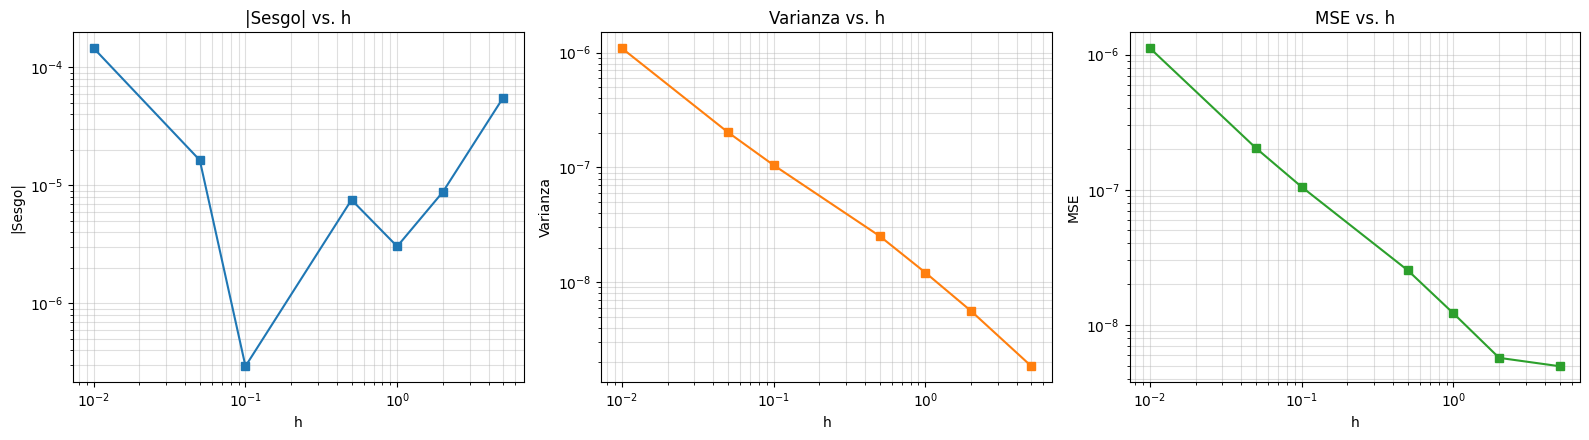

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].loglog(df_h["h"], df_h["AbsBias_FD"], "s-")
axes[0].set_xlabel("h"); axes[0].set_ylabel("|Sesgo|")
axes[0].set_title("|Sesgo| vs. h")
axes[0].grid(True, which="both", alpha=0.4)


axes[1].loglog(df_h["h"], df_h["Var_FD"], "s-", color="tab:orange")
axes[1].set_xlabel("h"); axes[1].set_ylabel("Varianza")
axes[1].set_title("Varianza vs. h")
axes[1].grid(True, which="both", alpha=0.4)

axes[2].loglog(df_h["h"], df_h["MSE_FD"], "s-", color="tab:green")
axes[2].set_xlabel("h"); axes[2].set_ylabel("MSE")
axes[2].set_title("MSE vs. h")
axes[2].grid(True, which="both", alpha=0.4)

plt.tight_layout()
plt.show()


**Lectura.**

- **Sesgo.** El sesgo de truncamiento es numéricamente muy pequeño en toda la malla explorada  y no muestra la pendiente +2 esperada de forma limpia: con $M=200$ réplicas, el error estándar del estimador de sesgo es comparable a su propio valor, de modo que la señal queda enmascarada por el ruido Monte Carlo. 
- **Varianza.** Crece aproximadamente como $1/h$ al disminuir $h$ en lugar de $\mathcal{O}(1/h^4)$ que correspondería a simulaciones independientes. La reducción es sustancial pero seguimos teniendo dependendenca en h por el residuo de Monte Carlo.
- **MSE.** Con  $N=10^6$, la curva en U es visible, si bien está desplazada hacia valores grandes de h: el mínimo se sitúa en torno a $h^\star \approx 2$.

El hecho de que $h^\star \sim \mathcal{O}(1)$ —y no $h^\star/S_0 \in [0.5\%,\, 1\%]$ como en Delta o Vega— nos muestra que Gamma FD requiere perturbaciones mucho más grandes para equilibrar sesgo y varianza, lo que a su vez amplifica el error de truncamiento y limita la precisión alcanzable con cualquier $N$ finito. Esto refuerza la dificultad operativa de FD para Griegas de segundo orden.


## 6. Conclusiones del notebook

1. **El método pathwise no aplica a Gamma**: el estimador directo es idénticamente nulo.
2. FD centrado de segundo orden recupera la $\Gamma$ analítica con tasa $\mathcal{O}(N^{-1/2})$. El CRN —misma $Z$ para las tres perturbaciones 
reduce la varianza de $\mathcal{O}(h^{-4})$ a $\mathcal{O}(h^{-1})$ empíricamente, lo que hace el estimador operativo en un rango razonable de $h$.
3. El compromiso sesgo–varianza es **más severo** que en primer orden: incluso con CRN, la varianza crece al reducir $h$, y el $h^\star$ óptimo se desplaza hacia valores grandes ($h^\star \sim \mathcal{O}(1)$ para $N = 10^6$). La curva en U del MSE solo es visible con $N$ elevado; para $N$ moderado, la varianza domina en todo el rango explorado.
